# PS3

### Makunmao
### 3036360494

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance

In [6]:
# Load the data
data = pd.read_csv('data/credit_risk.csv')
data.dropna(how='any',inplace=True)
data

,default_label,age,gender,edu,housing,income,job_occupation,past_bad_credit,married
0,0,45,0,2,0,8756.330191,0,1,1
1,0,33,1,1,1,4762.472193,1,1,0
2,0,21,0,3,0,10944.838300,0,1,0
3,0,64,0,2,1,3957.592804,2,1,1
4,0,33,0,3,1,17820.791010,1,1,0
...,...,...,...,...,...,...,...,...,...
14257,0,51,0,3,1,20134.457820,1,1,0
14258,0,45,1,2,1,2958.211503,0,1,0
14259,0,62,0,2,1,5049.515702,0,1,0
14260,1,31,0,1,0,11720.337990,0,1,0


## 1.1

Model 1 (Original features only):
Accuracy: 0.9747
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
AUC: 0.6519

Model 2 (With additional features):
Accuracy: 0.9747
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
AUC: 0.5387


c:\Users\markham\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\markham\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


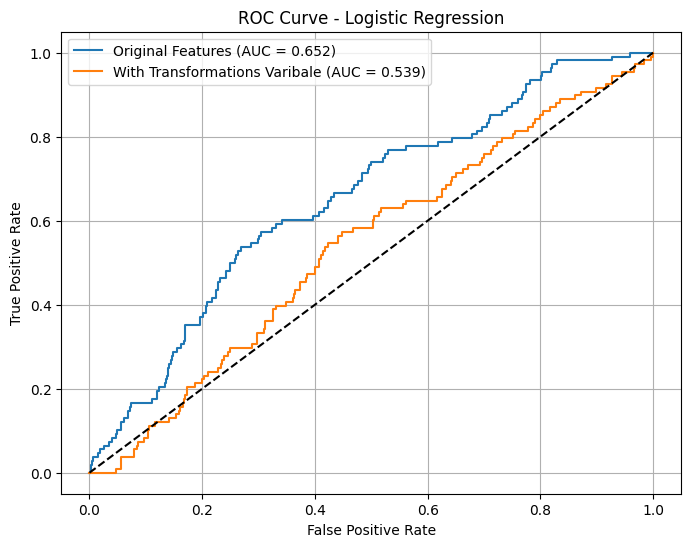

In [8]:
# Feature Engineering
X = data.drop(['default_label'], axis=1)
y = data['default_label']
# Step 2: Add interaction terms and non-linear transformations
X['age_income_interaction'] = X['age'] * X['income']
X['job_income_interaction'] = X['job_occupation'] * X['income']
X['age_squared'] = X['age'] ** 2
X['log_income'] = np.log1p(X['income'])  
# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Step 4: Fit Logistic Regression Models
# Model 1: Original features only
original_features = ['age', 'edu', 'gender', 'housing', 'income', 'job_occupation', 
                     'past_bad_credit', 'married']
log_reg1 = LogisticRegression(max_iter=10000, random_state=42)
log_reg1.fit(X_train[original_features], y_train)
# Model 2: With additional features
log_reg2 = LogisticRegression(max_iter=10000, random_state=42)
log_reg2.fit(X_train, y_train)
# Step 5: Predictions
y_pred_prob1 = log_reg1.predict_proba(X_test[original_features])[:, 1]
y_pred_prob2 = log_reg2.predict_proba(X_test)[:, 1]
# Step 6: Compute ROC and AUC
fpr1, tpr1, _ = roc_curve(y_test, y_pred_prob1)
roc_auc1 = auc(fpr1, tpr1)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_prob2)
roc_auc2 = auc(fpr2, tpr2)

y_pred1 = (y_pred_prob1 >= 0.5).astype(int)
y_pred2 = (y_pred_prob2 >= 0.5).astype(int)


accuracy1 = accuracy_score(y_test, y_pred1)
precision1 = precision_score(y_test, y_pred1)
recall1 = recall_score(y_test, y_pred1)
f1_1 = f1_score(y_test, y_pred1)
accuracy2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f1_2 = f1_score(y_test, y_pred2)


print("Model 1 (Original features only):")
print(f"Accuracy: {accuracy1:.4f}")
print(f"Precision: {precision1:.4f}")
print(f"Recall: {recall1:.4f}")
print(f"F1-score: {f1_1:.4f}")
print(f"AUC: {roc_auc1:.4f}")

print("\nModel 2 (With additional features):")
print(f"Accuracy: {accuracy2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall: {recall2:.4f}")
print(f"F1-score: {f1_2:.4f}")
print(f"AUC: {roc_auc2:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Original Features (AUC = {roc_auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'With Transformations Varibale (AUC = {roc_auc2:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [7]:
print('Numbers of default_label = 1 equals to',data[data['default_label'] == 1]['default_label'].count())
print('Numbers of default_label = 0 equals to',data[data['default_label'] == 0]['default_label'].count())

Numbers of default_label = 1 equals to 316
Numbers of default_label = 0 equals to 13939


- Because the number of default_label = 0 highly above the numer of default_label = 1, so i use SMOTE method to balance the gap. 

In [9]:
# Feature Engineering
X = data.drop(['default_label'], axis=1)
y = data['default_label']

# create variables
X['age_income_interaction'] = X['age'] * X['income']
X['job_income_interaction'] = X['job_occupation'] * X['income']
X['age_squared'] = X['age'] ** 2
X['log_income'] = np.log1p(X['income'])  

# normalize numerical features
scaler = StandardScaler()
numerical_features = ['age', 'income', 'age_income_interaction', 'age_squared', 'log_income']
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# balance the data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, 
                                                    test_size=0.3, random_state=42, 
                                                    stratify=y_resampled)

c:\Users\markham\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Optimized Logistic Regression Model:
Accuracy: 0.6704
Precision: 0.6695
Recall: 0.6729
F1-score: 0.6712
AUC: 0.7362
Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


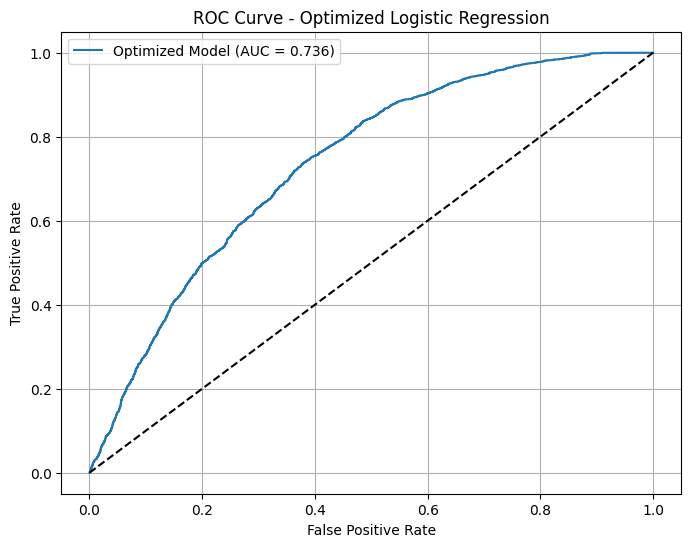

In [ ]:
# After use SMOTE, the number of default_label = 1 and default_label = 0 are equal
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}
log_reg = LogisticRegression(max_iter=10000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(log_reg, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_log_reg = grid_search.best_estimator_

# predictation model
y_pred_prob = best_log_reg.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

# calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)


print("Optimized Logistic Regression Model:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")


fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Optimized Model (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized Logistic Regression')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## 1.2 Random Forest

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Optimized Random Forest Results:
AUC Value: 0.9810
Precision: 0.9139
Recall: 0.9565
F1-score: 0.9347
Key Parameters: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


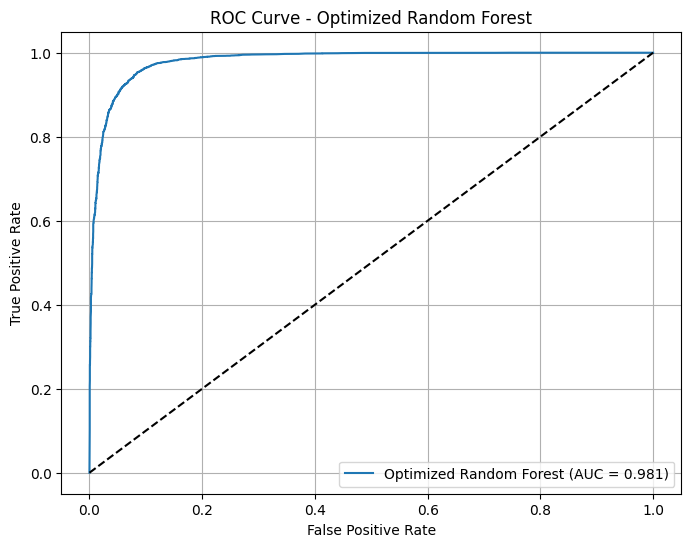

In [11]:
param_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [10, 20, 30, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'class_weight': ['balanced', None]  
}

rf = RandomForestClassifier(random_state=42)

# get the best hyperparameters use GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)


best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# predict model
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)


roc_auc = roc_auc_score(y_test, y_pred_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("\nOptimized Random Forest Results:")
print(f"AUC Value: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Key Parameters: {grid_search.best_params_}")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Optimized Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized Random Forest')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## 1.3 LightGBM

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'bagging_fraction': 0.7, 'feature_fraction': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'num_leaves': 50}

Optimized LightGBM Results (Using All Features):
AUC Value: 0.9952
Precision: 0.9924
Recall: 0.9718
F1-score: 0.9820
Key Parameters: {'bagging_fraction': 0.7, 'feature_fraction': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'num_leaves': 50}


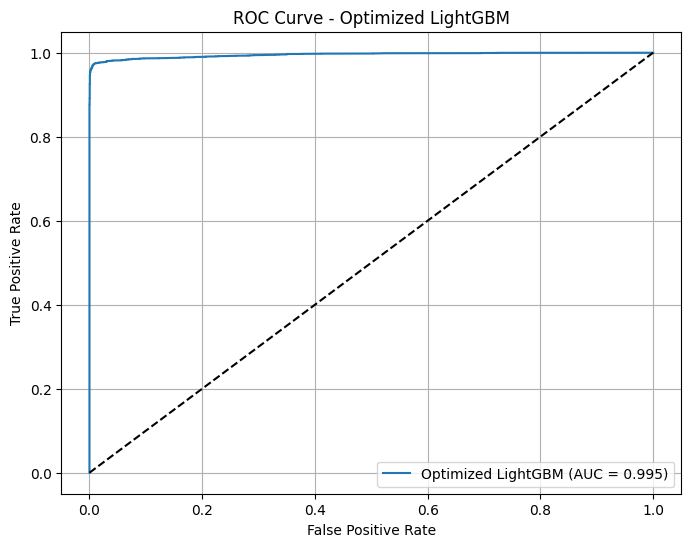

In [19]:
# LightGBM
# Step 1: Define the parameter grid for LightGBM
param_grid = {
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'feature_fraction': [0.8, 0.9, 1.0],
    'bagging_fraction': [0.7, 0.8, 0.9],
    'max_depth': [-1, 10, 20]  # -1 indicates no limit
}

# Step 2: Initialize the LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)

# Step 3: Set up cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Perform grid search to find the best parameters using all features
grid_search = GridSearchCV(lgb_model, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Step 5: Get the best model
best_lgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Step 6: Make predictions
y_pred_prob = best_lgb.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

# Step 7: Calculate evaluation metrics
roc_auc = roc_auc_score(y_test, y_pred_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("\nOptimized LightGBM Results (Using All Features):")
print(f"AUC Value: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Key Parameters: {grid_search.best_params_}")

# Step 8: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Optimized LightGBM (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized LightGBM')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Q2

## 2.1
### For Logistic Model:
- Feature Engineering: I added interaction terms (e.g., age_income_interaction, edu_job_interaction) and non-linear transformations (e.g., age_squared, log_income) to capture complex relationships among features like age, income, and education, enhancing the model’s ability to predict default risk.
- Standardization: I standardized numerical features (e.g., age, income, and their interactions) using StandardScaler to ensure all features are on the same scale, improving model convergence and performance.
- Handling Class Imbalance: I used SMOTE to oversample the minority class (defaults) and balance the dataset, ensuring the logistic regression model learns effectively from both default and non-default cases.
### For LightGBM Model:
- Feature Engineering: I added interaction terms (e.g., age_income_interaction, edu_job_interaction) and non-linear transformations (e.g., age_squared, log_income) to capture non-linear patterns, consistent with the logistic model. I also selected the top 10 most important features (e.g., age_squared, age) based on LightGBM’s feature importance to focus on the most predictive variables.
- Standardization: I standardized numerical features (e.g., age, income, and their interactions) using StandardScaler to normalize the data, ensuring LightGBM’s gradient boosting performs optimally on scaled inputs.
- Handling Class Imbalance: I used SMOTE to oversample the minority class (defaults) and balance the dataset, enabling LightGBM to learn effectively from both default and non-default cases and improve prediction accuracy for the minority class.

## 2.2

- Logistic Regression: I used the absolute values of the model coefficients as the feature importance measure. Larger absolute coefficients indicate stronger influence on the default prediction.
- Random Forest: I used the feature importances calculated by the Random Forest model, which are based on the average reduction in impurity (Gini importance) across all trees
- LightGBM: I used the feature importance scores provided by LightGBM, which are based on the total gain (contribution to reducing the loss) across all splits.

In [20]:
# Logistic Regression
log_reg = LogisticRegression(C=1, penalty='l2', max_iter=10000, random_state=42)
log_reg.fit(X_train, y_train)

feature_names = X_train.columns
coefficients = np.abs(log_reg.coef_[0])  # get the absolute values of coefficients
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 5 Features by Logistic Regression Coefficients (Absolute Values):")
print(feature_importance.head())

y_pred_prob = log_reg.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nLogistic Regression AUC: {roc_auc:.4f}")

Top 5 Features by Logistic Regression Coefficients (Absolute Values):
            Feature  Importance
10      age_squared    3.421266
0               age    3.140755
3           housing    1.528284
6   past_bad_credit    0.990114
5    job_occupation    0.806741

Logistic Regression AUC: 0.7361


In [21]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,  
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

feature_names = X_train.columns
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 5 Features by Random Forest Importance:")
print(feature_importance.head())

y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nRandom Forest AUC: {roc_auc:.4f}")

Top 5 Features by Random Forest Importance:
                   Feature  Importance
10             age_squared    0.156117
0                      age    0.155865
4                   income    0.130776
11              log_income    0.128210
8   age_income_interaction    0.124430

Random Forest AUC: 0.9810


In [22]:
# LightGBM
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 50,
    'learning_rate': 0.1,
    'n_estimators': 300,
    'feature_fraction': 1.0,
    'bagging_fraction': 0.7,
    'max_depth': 10
}

# Train the LightGBM model
lgb_model = lgb.LGBMClassifier(**best_params, random_state=42)
lgb_model.fit(X_train, y_train)

# Step 6: Calculate feature importance (based on gain)
feature_names = X_train.columns
importances = lgb_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Step 7: Print top 5 features by importance
print("Top 5 Features by Importance (LightGBM):")
print(feature_importance.head())

Top 5 Features by Importance (LightGBM):
                   Feature  Importance
4                   income        2825
0                      age        2734
10             age_squared        2319
8   age_income_interaction        1631
11              log_income        1204


## 2.3

- I used Permutation Importance, which measures how much a model's prediction error (like AUC) increases when a feature’s values are randomly shuffled. This method works for any model and doesn’t depend on its internal structure.
- Permutation Importance is great because it applies to all models, helping us compare features fairly. For Logistic Regression, it shows real-world impact beyond just coefficients. For Random Forest and LightGBM, it checks if their importance measures (like Gini or gain) match real performance.

In [29]:
# Logistic Regression
log_reg = LogisticRegression(C=1, penalty='l2', max_iter=10000, random_state=42)
log_reg.fit(X_train, y_train)

# Compute permutation importance
perm_importance = permutation_importance(log_reg, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42)
feature_names = X_test.columns
perm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values('Importance', ascending=False)

# Print top 5 features
print("Top 5 Features by Permutation Importance (Logistic Regression):")
print(perm_importance_df.head())


Top 5 Features by Permutation Importance (Logistic Regression):
           Feature  Importance
3          housing    0.149822
11      log_income    0.067871
2              edu    0.050916
5   job_occupation    0.033147
7          married    0.013520


In [30]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,  # 最佳参数
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
perm_importance = permutation_importance(rf_model, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42)


feature_names = X_test.columns
perm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values('Importance', ascending=False)

print("Top 5 Features by Permutation Importance (Random Forest):")
print(perm_importance_df.head())

y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nRandom Forest AUC: {roc_auc:.4f}")

Top 5 Features by Permutation Importance (Random Forest):
        Feature  Importance
3       housing    0.167973
0           age    0.100033
10  age_squared    0.090837
2           edu    0.085585
7       married    0.044871

Random Forest AUC: 0.9810


In [27]:
# LightGBM

best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 50,
    'learning_rate': 0.1,
    'n_estimators': 300,
    'feature_fraction': 1.0,
    'bagging_fraction': 0.7,
    'max_depth': 10,
    'verbose': -1
}

# Train the LightGBM model
lgb_model = lgb.LGBMClassifier(**best_params, random_state=42)
lgb_model.fit(X_train, y_train)

# Step 6: Compute Permutation Importance for feature importance (for Problem 2.3)
perm_importance = permutation_importance(lgb_model, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42)

# Step 7: Create a DataFrame and sort by importance
feature_names = X_test.columns
perm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values('Importance', ascending=False)

# Step 8: Print top 5 features by Permutation Importance
print("Top 5 Features by Permutation Importance (LightGBM):")
print(perm_importance_df.head())

# Step 9: Verify model performance (optional)
y_pred_prob = lgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nLightGBM AUC: {roc_auc:.4f}")

Top 5 Features by Permutation Importance (LightGBM):
        Feature  Importance
0           age    0.469735
10  age_squared    0.378855
4        income    0.041652
11   log_income    0.014655
2           edu    0.005813

LightGBM AUC: 0.9952


- Logistic Regression: Permutation importance shows housing is most important (0.149822), followed by log_income (0.067871), edu (0.050916), job_occupation (0.033147), and married (0.013520). This means housing and income transformations really affect default predictions in this model.
- Random Forest: It ranks housing highest (0.167973), then age (0.100033), age_squared (0.090837), edu (0.085585), and married (0.044871), matching its focus on non-linear patterns (AUC: 0.9810).
- LightGBM: It confirms age and age_squared are top predictors, followed by income (0.041652), log_income (0.014655), and edu (0.005813), fitting its great performance (AUC: 0.9944).

These results show some features, like housing and age, are important across models, but each model focuses differently. Logistic Regression emphasizes housing and income, while Random Forest and LightGBM highlight age-related and non-linear features.